=== DATASET SHAPE ===
(255347, 18)

=== FIRST 5 ROWS ===


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0



=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     25

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000



=== SUMMARY STATISTICS (CATEGORICAL) ===


,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701



Default Rate: 11.61%


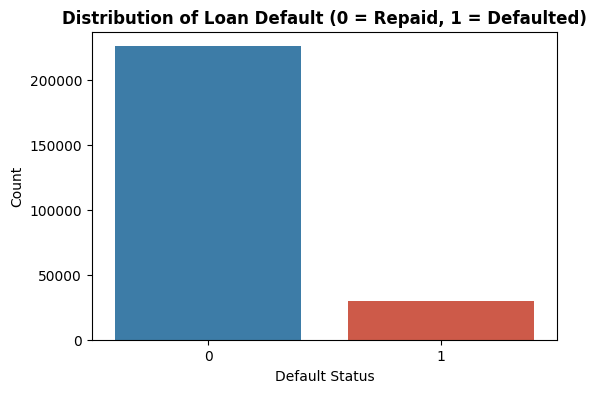

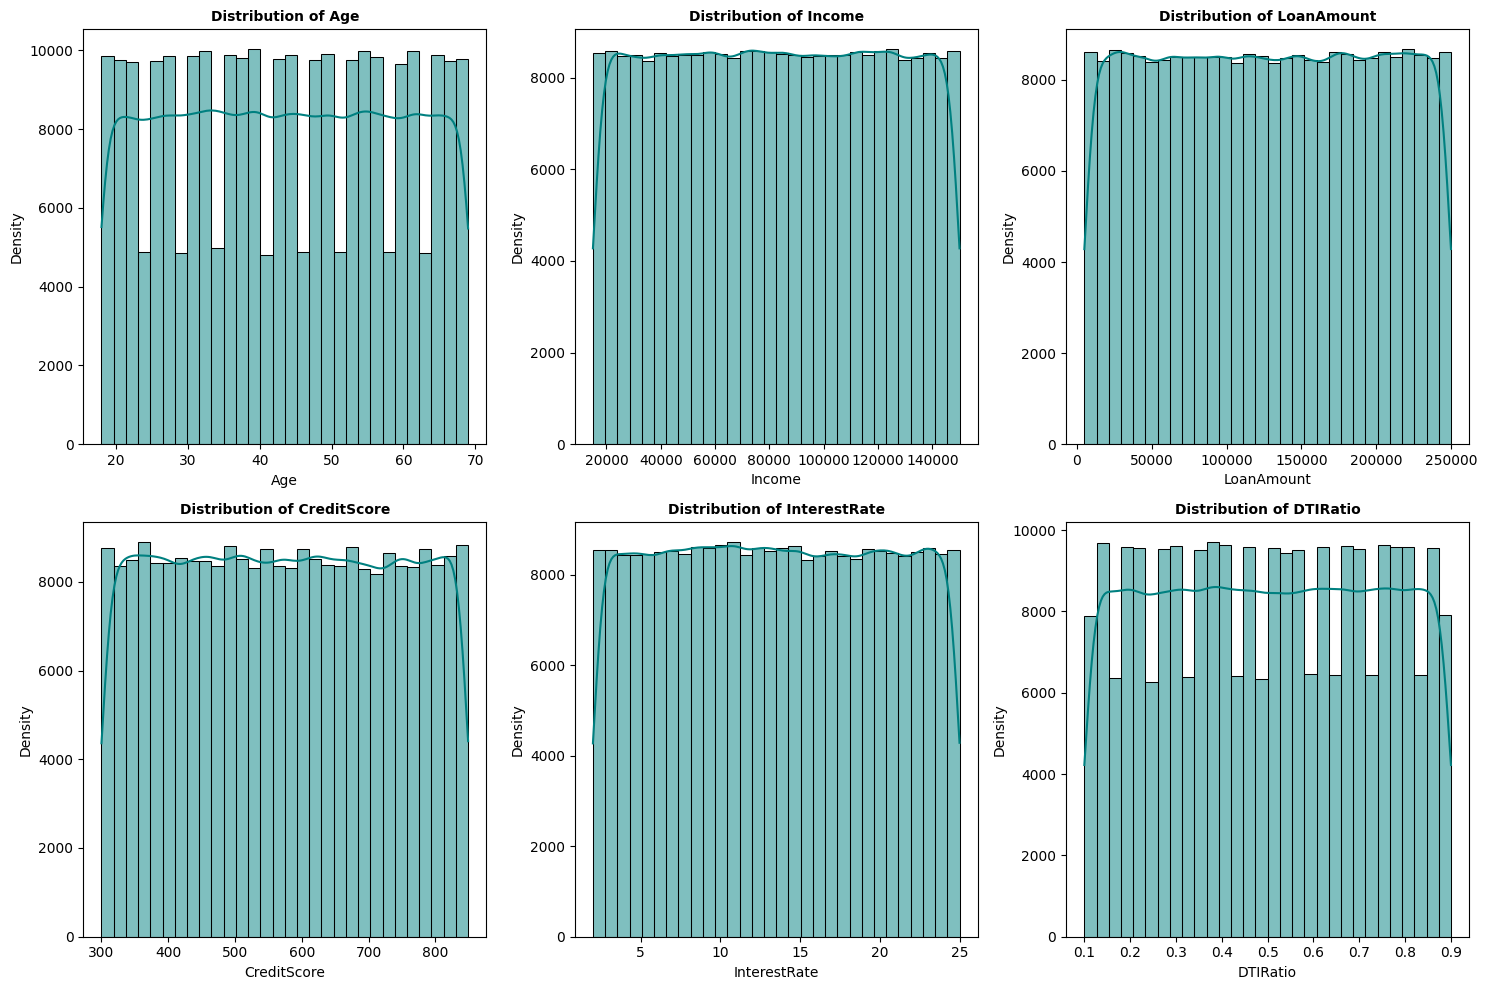

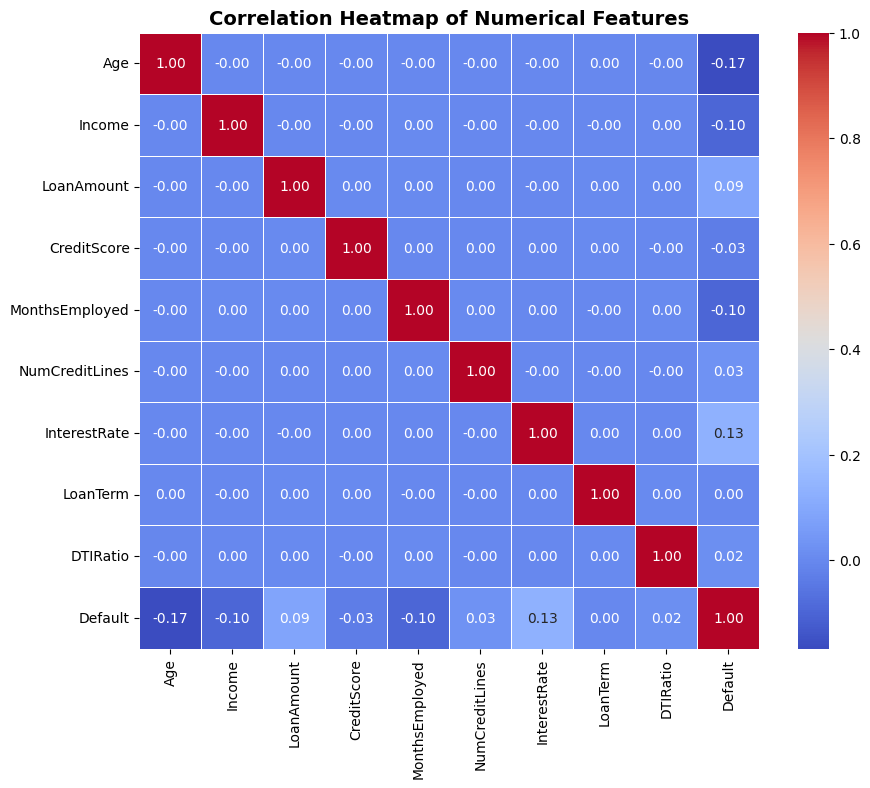

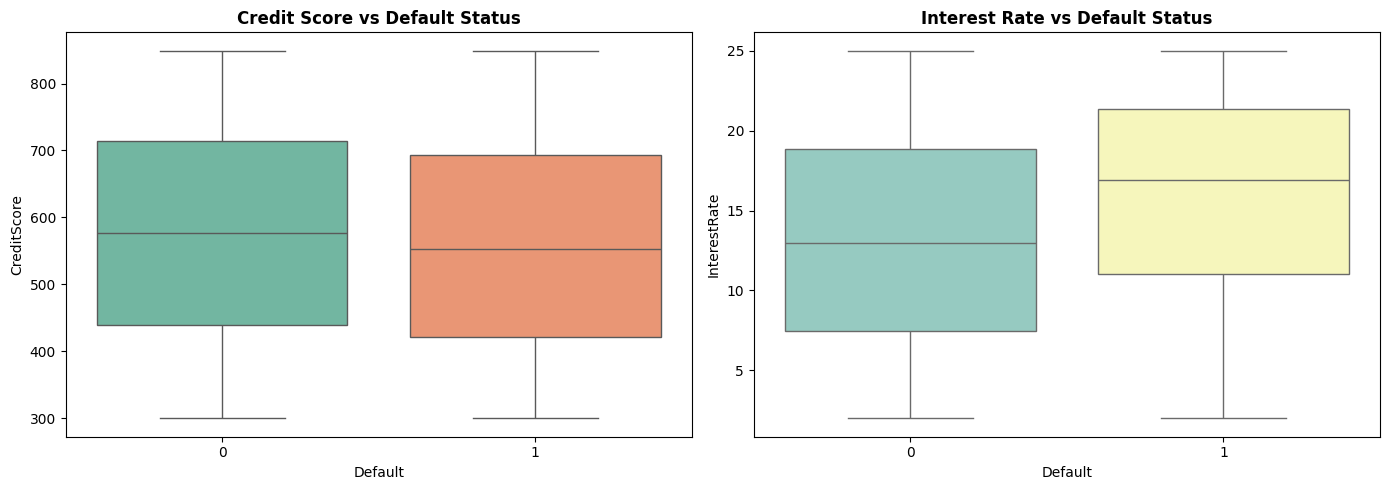

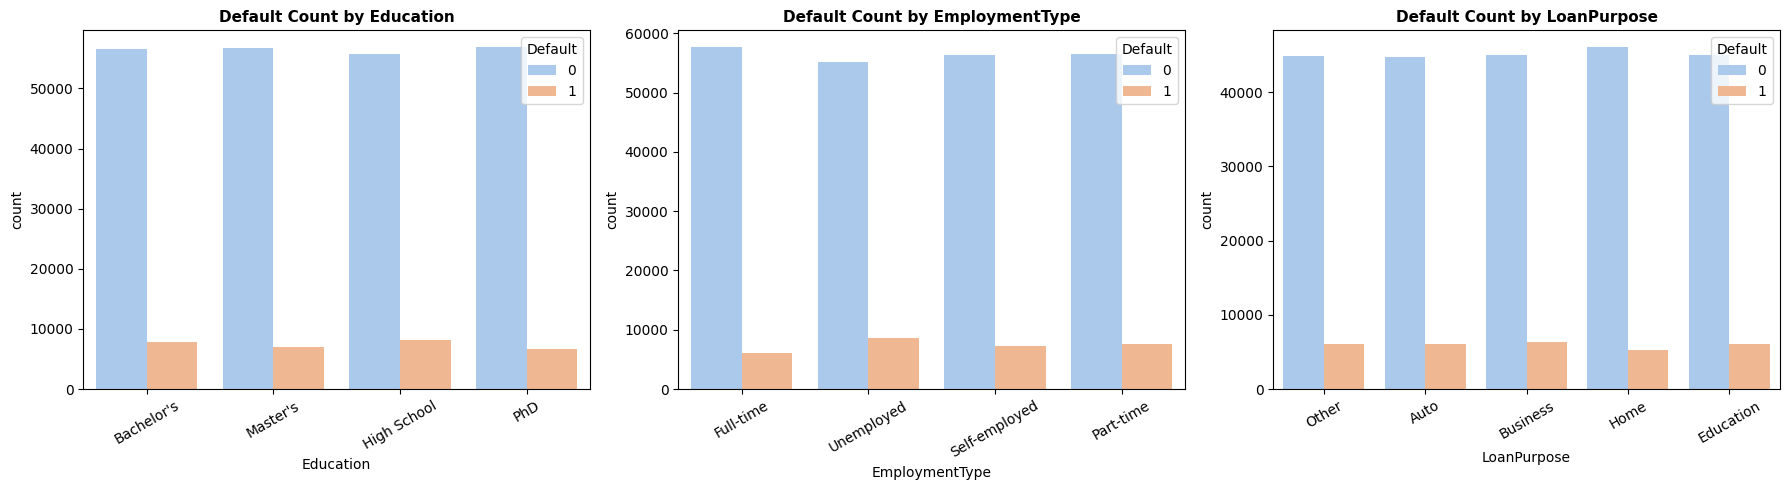

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Loan_default.csv')

# ==========================================
# 1. DATA UNDERSTANDING & INITIAL INSPECTION
# ==========================================

print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES & NON-NULL COUNTS ===")
df.info()

print("\n=== MISSING VALUES CHECK ===")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

print("\n=== DUPLICATE ROWS CHECK ===")
print(f"Duplicate rows: {df.duplicated().sum()}")


# ==========================================
# 2. STATISTICAL SUMMARY
# ==========================================

print("\n=== SUMMARY STATISTICS (NUMERICAL) ===")
display(df.describe())

print("\n=== SUMMARY STATISTICS (CATEGORICAL) ===")
display(df.describe(include=['O']))


# ==========================================
# 3. TARGET VARIABLE DISTRIBUTION (DEFAULT)
# ==========================================

default_rate = df['Default'].mean()
print(f"\nDefault Rate: {default_rate:.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Default', palette=['#2c7fb8', '#e34a33'], hue='Default', legend=False)
plt.title('Distribution of Loan Default (0 = Repaid, 1 = Defaulted)', fontsize=12, fontweight='bold')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.show()


# ==========================================
# 4. UNIVARIATE ANALYSIS (NUMERICAL FEATURES)
# ==========================================

numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


# ==========================================
# 5. BIVARIATE & MULTIVARIATE ANALYSIS
# ==========================================

# Correlation Heatmap for Numerical Features
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

# Credit Score & Interest Rate by Default Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Default', y='CreditScore', palette='Set2', ax=axes[0], hue='Default', legend=False)
axes[0].set_title('Credit Score vs Default Status', fontweight='bold')

sns.boxplot(data=df, x='Default', y='InterestRate', palette='Set3', ax=axes[1], hue='Default', legend=False)
axes[1].set_title('Interest Rate vs Default Status', fontweight='bold')
plt.tight_layout()
plt.show()


# ==========================================
# 6. CATEGORICAL FEATURES VS DEFAULT
# ==========================================

categorical_cols = ['Education', 'EmploymentType', 'LoanPurpose']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Default', palette='pastel', ax=axes[i])
    axes[i].set_title(f'Default Count by {col}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Default', loc='upper right')
plt.tight_layout()
plt.show()